## Assignment 2


In [77]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display, Math

In [ ]:
# --------------------------
# Constants and known values
# --------------------------
Q = 3.0                 # Discharge [m^3/s]
S_1 = 0.001             # Slope in case 1 [-]
S_2 = 0.01              # Slope in case 2 [-]
d_g = 0.001             # Grain diameter [m]
k_s = 2.5 * d_g         # Nikuradse's equivalent sand grain roughness [m]
L = 10.0                # Length of the bottom undulation [m]
b = 0.1                 # Amplitude of the bottom undulation [m]
g = 9.81                # Gravitational acceleration [m/s^2]
viscosity = 1.003e-6    # Kinematic viscosity [m^2/s]

In [70]:
# --------------------------
# Determining type of flow
# --------------------------
def determine_flow_type(velocity, depth):
    Froude_number = velocity / np.sqrt(g * depth)

    if Froude_number < 1:
        flow_type = "Subcritical"
    else:
        flow_type = "Supercritical"

    return flow_type, Froude_number

In [71]:
# --------------------------
# Determining Dnorm
# --------------------------
def calculate_Dnorm(Q, u):
    D_norm = Q / u  # Normal depth diameter [m]
    return D_norm

### Question 1
Consider a steady, uniform flow in a wide river with discharge (per unit width) q=3 m2/s, slope S=0.001, and with bed sediment grains having diameter d=1 mm. By combining the flow resistance equation u=sqrt(2*g*D*S/f) with the Colebrook-White equation, solve for the normal depth D. What is the resulting velocity and Froude number? Repeat this exercise with the steeper channel slope S=0.01. (HINT: You should obtain examples of both subcritical and supercritical flow)

In [72]:
# ------------------------------------------
# System of equations for subcritical case
# ------------------------------------------
def equations_subcritical(unknowns, slope):
    f, u = unknowns

    # Cross-sectional area and velocity
    D_norm = Q / u                       # Normal depth diameter [m]
    R = D_norm                           # Hydraulic radius [m] (R=D for wide channels)
    Re = R * u / viscosity               # Reynolds number [-]

    # Colebrook equation
    colebrook = np.sqrt(2 / f) - (6.4 - 2.45 * np.log(k_s / R + 4.7 / (Re * np.sqrt(f))))

    # Flow Resistance equation
    flow_resist = u - np.sqrt((2 * g * D_norm * slope) / f)

    return [colebrook, flow_resist]


In [73]:
# -------------------------------
# Solve the system for slope S_1
# -------------------------------
initial_guess = [0.0001, 0.01]  # [f, u]
solution = fsolve(equations_subcritical, initial_guess, args=(S_1,))
f_sol_1, u_sol_1 = solution

# --------------------------
# Output results
# --------------------------
print("For slope S_1:", S_1)
print(f"Friction factor f: {f_sol_1:.6f}")
print(f"Velocity u: {u_sol_1:.6f} m/s")

D_norm_1 = calculate_Dnorm(Q, u_sol_1)
print(f"Normal depth diameter D: {D_norm_1:.6f} m")

flow_type_1, Fr_1 = determine_flow_type(u_sol_1, D_norm_1)
print(f"Flow type: {flow_type_1}\nFroude number: {Fr_1:.6f}")

For slope S_1: 0.001
Friction factor f: 0.004286
Velocity u: 2.394737 m/s
Normal depth diameter D: 1.252747 m
Flow type: Subcritical
Froude number: 0.683111


In [74]:
# -------------------------------
# Solve the system for slope S_2
# -------------------------------
initial_guess = [0.0001, 0.01]  # [f, u]
solution = fsolve(equations_subcritical, initial_guess, args=(S_2,))
f_sol_2, u_sol_2 = solution

print("\nFor slope S_2:", S_2)
print(f"Friction factor f: {f_sol_2:.6f}")
print(f"Velocity u: {u_sol_2:.6f} m/s")

D_norm_2 = calculate_Dnorm(Q, u_sol_2)
print(f"Normal depth diameter D: {D_norm_2:.6f} m")

flow_type_2, Fr_2 = determine_flow_type(u_sol_2, D_norm_2)
print(f"Flow type: {flow_type_2}\nFroude number: {Fr_2:.6f}")


For slope S_2: 0.01
Friction factor f: 0.005064
Velocity u: 4.880323 m/s
Normal depth diameter D: 0.614713 m
Flow type: Supercritical
Froude number: 1.987365


### Question 2
Now consider the shallow water flow over a wavy bed, with bed undulation given by:h = b * sin(2*pi*x/L), where L=10 m is the wavelength of the bottom undulation, and its amplitude taken as b = 0.1 m. Based on the two unperturbed flow situations found above (i.e. subcritical and supercritical flow), plot the resulting wavy bottom and induced free surface elevations (plot all three on the same figure to ease comparison)

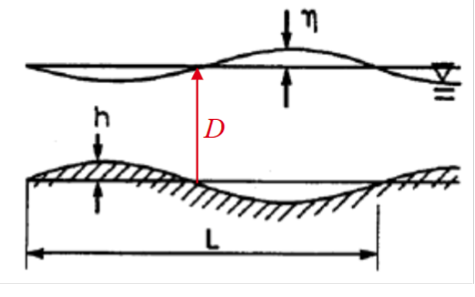

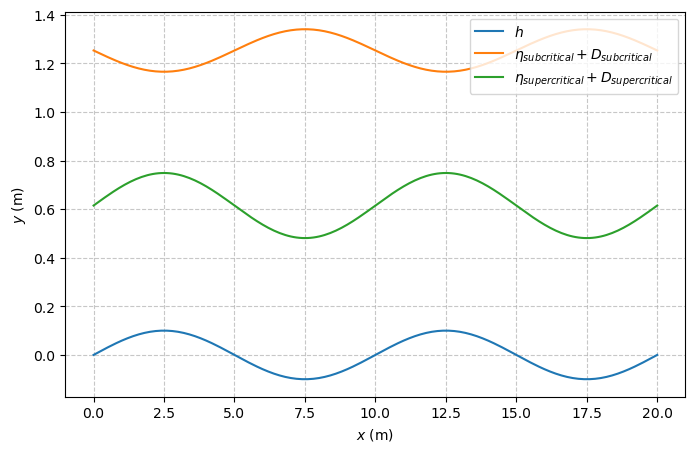

In [75]:
# -------------------------------
# Function for bottom undulation
# -------------------------------
x = np.arange(0, 2 * L + 0.1, 0.1)      # x-coordinates

# Function for bottom undulation
h = b * np.sin(2 * np.pi * x / L)       # wavy bed

# Free surface elevations
eta_sub = b * np.sin(2 * np.pi * x / L) * (Fr_1**2 / (Fr_1**2 - 1))
eta_super = b * np.sin(2 * np.pi * x / L) * (Fr_2**2 / (Fr_2**2 - 1))

# -------------------------------
# Plot results
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(x, h, label=r"$h$")
plt.plot(x, eta_sub + D_norm_1, label=r"$\eta_{subcritical}+D_{subcritical}$")
plt.plot(x, eta_super + D_norm_2, label=r"$\eta_{supercritical}+D_{supercritical}$")

plt.xlabel(r"$x$ (m)")
plt.ylabel(r"$y$ (m)")
plt.legend(loc="upper right")
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.show()


In [80]:
x = sp.symbols('x')
latex_str = sp.latex(h)
display(Math(latex_str))

<IPython.core.display.Math object>